In [2]:


import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from windrose import WindroseAxes
from matplotlib import cm


In [3]:
caminho = "/home/matheus/Documentos/GitHub/LACRIO/Analises/Cordillera Blanca/Weather Station Data/Cuchillacocha_CUCHWX_5Jul13_6Apr20.csv"

df_estacao = pd.read_csv(caminho, encoding="latin1" )

In [4]:
df = pd.DataFrame({
    "data_hora": pd.to_datetime(df_estacao["Datetime"]),
    "velocidade_vento_m_s": df_estacao["Wind Speed (m/s)"],
    "direcao_vento_graus": df_estacao["Wind Direction (°)"],
    "rajada_vento_m_s": df_estacao["Gust Speed (m/s)"],
})

In [6]:
df_completo = df 

/tmp/ipykernel_27299/1740037018.py:32: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


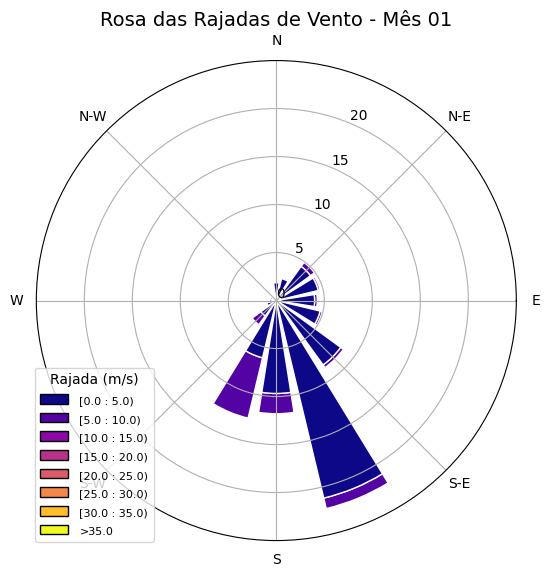

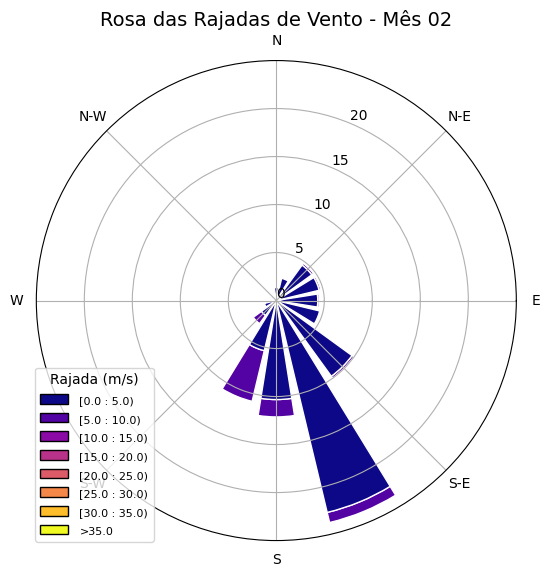

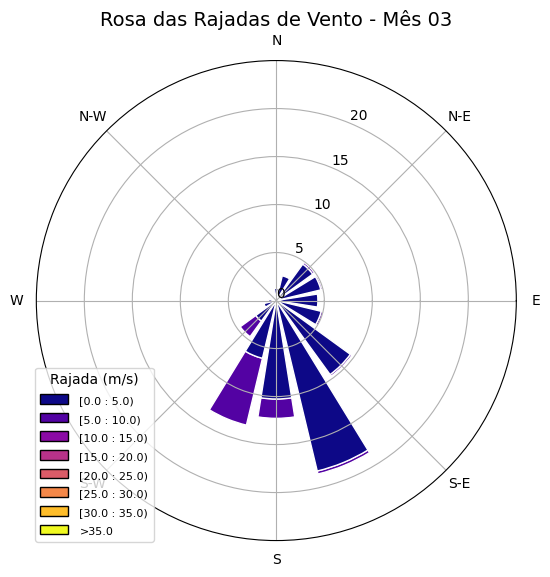

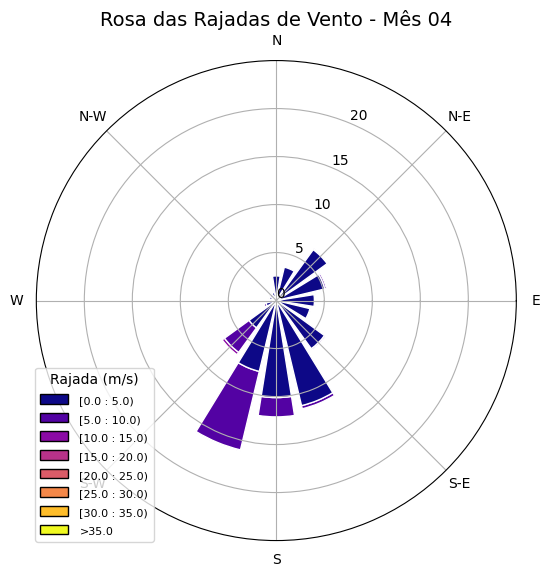

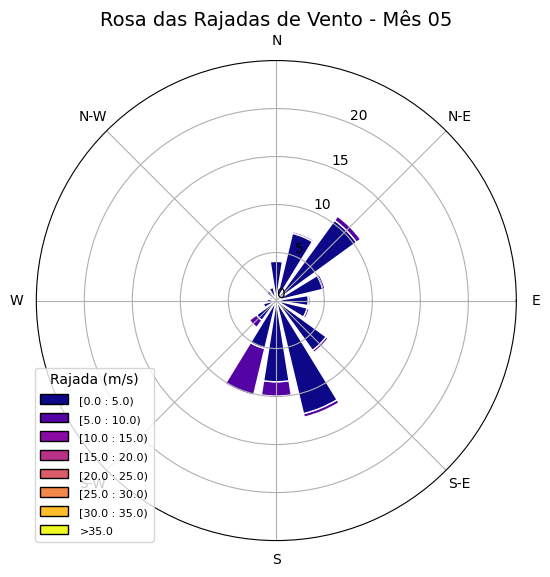

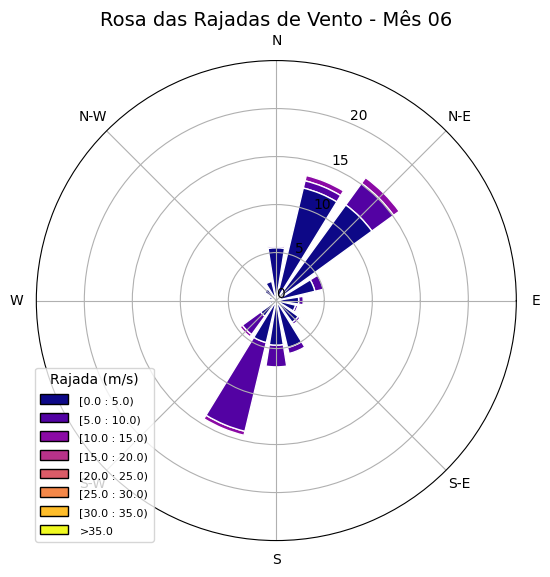

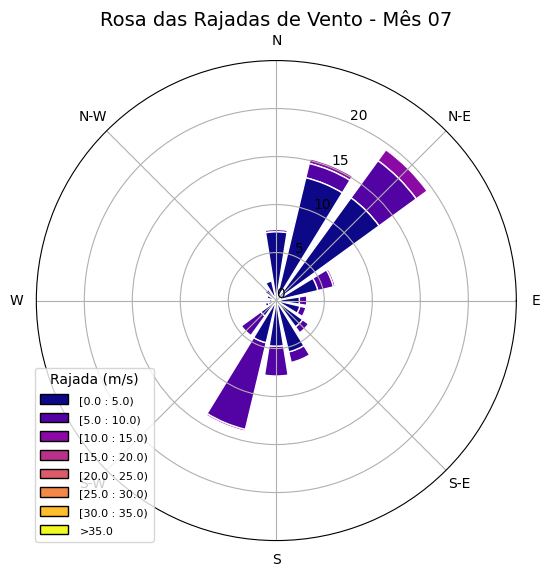

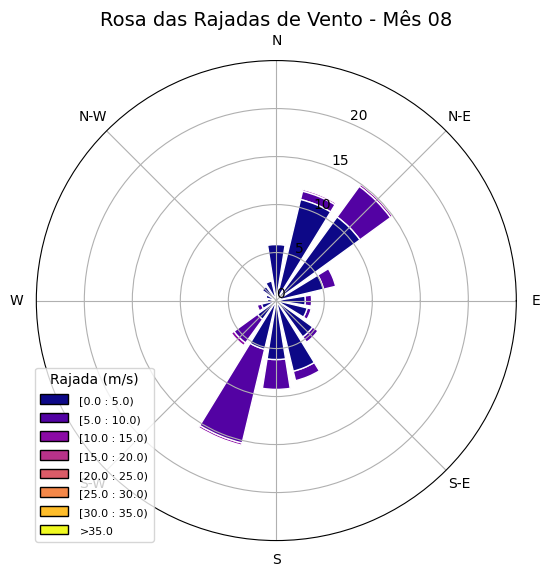

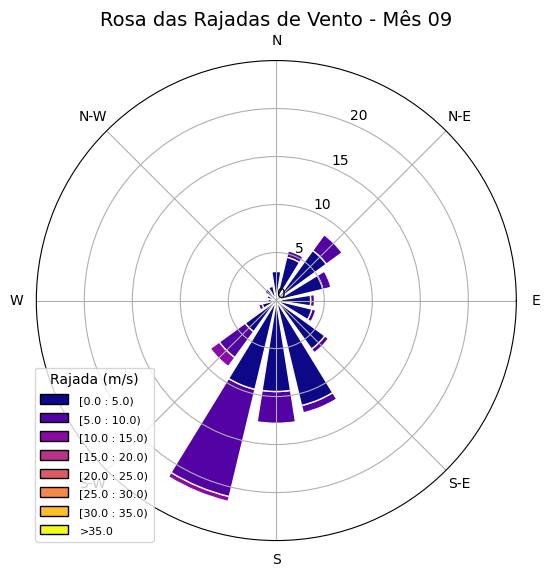

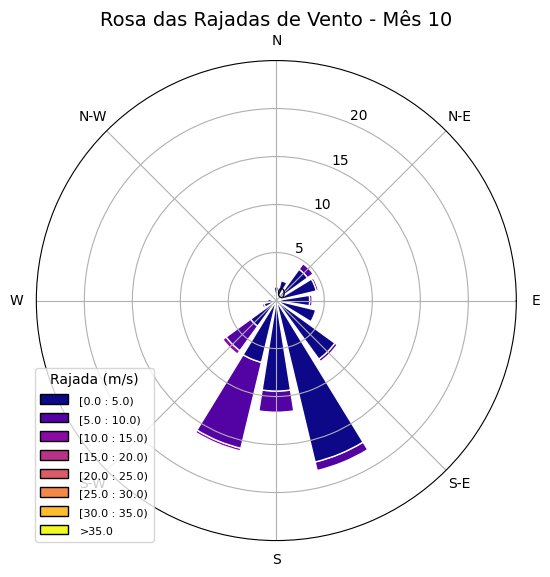

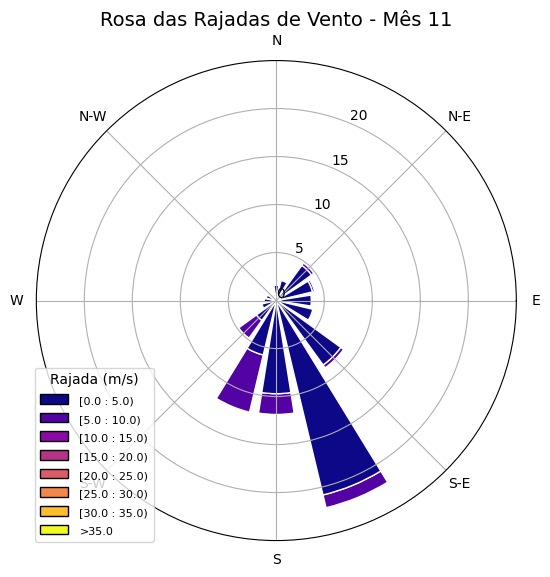

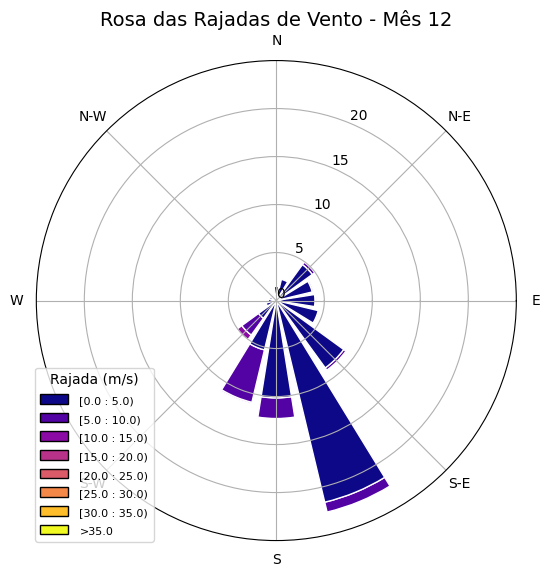

In [7]:

# Ensure the "mes" column exists in df_completo
if "mes" not in df_completo.columns:
    df_completo["mes"] = df_completo["data_hora"].dt.month

for mes in range(1, 13):
    df_mes = df_completo[df_completo["mes"] == mes]
    if df_mes.empty:
        continue

    fig = plt.figure(figsize=(6, 6))
    ax  = WindroseAxes.from_ax(fig=fig)

    # Desenha a rosa com bins de 0 a 35 m/s em passos de 5
    ax.bar(df_mes['direcao_vento_graus'],
           df_mes['rajada_vento_m_s'],
           normed=True,
           opening=0.8,
           edgecolor='white',
           bins=np.arange(0, 40, 5),
           cmap=cm.plasma)

    # 1) força o raio máximo em 25
    ax.set_rmax(25)

    # 2) define os yticks (intensidades) e seus rótulos
    yticks = np.arange(0, 25, 5)   # [ 0,  5, 10, 15, 20, 25]
    ax.set_yticks(yticks)
    ax.set_yticklabels([f"{int(y)}" for y in yticks])

    ax.set_title(f"Rosa das Rajadas de Vento - Mês {mes:02d}", fontsize=14)
    ax.set_legend(title="Rajada (m/s)")
    plt.tight_layout()
    plt.show()
